Groundwater | Flow Modeling Track

# Step 7: Sensitivity & Uncertainty — Which Parameters Matter, and How Confident Are We?

> **The 10 steps at a glance:** 1-Goal → 2-Perceptual → 3-MODFLOW → 4-Build → 5-Calibrate → 6-Validate → **7-Sensitivity** → 8-Apply → 9-Document → 10-Communicate

**Story so far:** In Step 5 you calibrated the Limmat Valley model with PEST++, using 20 pilot points and 9 observations (4 real AWEL wells + 5 synthetic). In Step 6 you tested predictive capability with leave-one-out cross-validation. During calibration, PEST++ computed the **Jacobian matrix** — the sensitivity of every observation to every parameter. We just need to read it.

In this notebook we use **First-Order Second Moment (FOSM)** analysis via pyEMU's `Schur` class to answer:
- Which parameters does our observation network actually constrain?
- How much did calibration reduce parameter uncertainty?
- How uncertain are our head predictions?
- Where should we add monitoring wells to improve predictions?

**No model runs** — every computation is a fast matrix operation on PEST++ outputs (<1 second total).

| **Core content** | ~10–15 minutes |
|:--|:--|
| **Optional: Advanced sensitivity & uncertainty analysis** | +30–35 minutes |

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Explain** how the Jacobian matrix captures parameter–observation sensitivities
2. **Interpret** composite scaled sensitivities to rank parameter importance
3. **Distinguish** between parameter sensitivity and identifiability *(optional)*
4. **Quantify** prior vs posterior parameter uncertainty from calibration *(optional)*
5. **Evaluate** prediction uncertainty using FOSM (Schur complement) *(optional)*
6. **Recommend** where additional monitoring would most reduce uncertainty *(optional)*

---

## Prerequisites

Before starting this notebook, you should have:
- **Completed [5_calibration.ipynb](5_calibration.ipynb)** — the calibration workspace with PEST++ outputs must exist
- Familiarity with pilot points and calibration metrics from Step 5
- LOO-RMSE from [6_validation.ipynb](6_validation.ipynb)

In [4]:
# Setup
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import geopandas as gpd

import pyemu

import flopy
from flopy.mf6 import MFSimulation

from IPython.display import display, HTML

# Add support modules to path
sys.path.append(os.path.abspath('../../_SUPPORT/src'))
sys.path.append(os.path.abspath('../../_SUPPORT/src/scripts'))
sys.path.append(os.path.abspath('../../_SUPPORT/src/scripts/scripts_exercises'))

from data_utils import get_default_data_folder
from model_io_utils import load_base_simulation
from plot_utils import quick_model_plot

# Checkpoint utilities
from shared_functions import check_task_with_solution, create_multiple_choice

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12

# --- Load PEST++ outputs from NB5 calibration ---
print("--- Load PEST++ outputs from NB5 calibration ---")
DATA_DIR = get_default_data_folder()
pest_ws = os.path.join(DATA_DIR, 'calibration', 'pest_setup')

if not os.path.exists(os.path.join(pest_ws, 'calibration.pst')):
    raise FileNotFoundError(
        f"PEST++ outputs not found at {pest_ws}\n"
        "Please run Notebook 5 first."
    )

# Load PST control file
pst = pyemu.Pst(os.path.join(pest_ws, 'calibration.pst'))
print(f"Parameters: {pst.npar}")
print(f"Observations: {pst.nobs}")
print(f"Parameter groups: {list(pst.parameter_data['pargp'].unique())}")
print(f"Observation groups: {list(pst.observation_data['obgnme'].unique())}")

# --- Load model grid for spatial plots ---
print("--- Load model grid for spatial plots ---")
nb4_workspace = os.path.join(DATA_DIR, 'notebook4_model')
sim = load_base_simulation(nb4_workspace)
gwf = sim.get_model('limmat_valley')
modelgrid = gwf.modelgrid
modelgrid.set_coord_info(crs="EPSG:2056")

disv = gwf.get_package('DISV')
idomain = disv.idomain.array

# Load boundary and pilot points
from data_utils import download_named_file
boundary_path = download_named_file(name='model_boundary', data_type='gis')
boundary_gdf = gpd.read_file(boundary_path)

pp_df = pd.read_csv(os.path.join(pest_ws, 'pilot_points.csv'))
print(f"Pilot points: {len(pp_df)}")
print(f"Active cells: {(idomain.flatten() > 0).sum()}")

--- Load PEST++ outputs from NB5 calibration ---
Parameters: 21
Observations: 9
Parameter groups: ['hk_grp', 'riv_grp']
Observation groups: ['heads']
--- Load model grid for spatial plots ---
Loading MODFLOW 6 simulation from: /Users/louisenoel/applied_groundwater_modelling_data/limmat/notebook4_model
  Simulation name: mfsim.nam
  Models: ['limmat_valley']
  limmat_valley packages: ['disv', 'npf', 'ic', 'chd_0', 'rcha_0', 'wel_0', 'riv_0', 'oc']
limmat_model_boundary.gpkg already exists in /Users/louisenoel/applied_groundwater_modelling_data/limmat/gis.
limmat_model_boundary_readme.md already exists in /Users/louisenoel/applied_groundwater_modelling_data/limmat/gis.
Pilot points: 20
Active cells: 4845


---

## 1 — The Jacobian Matrix

### 1.1 - What is the Jacobian?

The **Jacobian matrix** $\mathbf{J}$ contains the partial derivatives of each observation with respect to each parameter:

$$J_{ij} = \frac{\partial h_i}{\partial p_j}$$

where $h_i$ is the simulated head at observation $i$ and $p_j$ is parameter $j$.

PEST++ computes this during calibration by running the model with each parameter perturbed slightly and recording how every observation changes. For our problem:
- **Rows** = 9 observations (4 real + 5 synthetic wells)
- **Columns** = 21 parameters (20 pilot-point log₁₀K + 1 Sihl leakance multiplier)

### 1.2 - Why FOSM works

First-Order Second Moment (FOSM) analysis uses the Jacobian to propagate uncertainty without re-running the model. The key equation (Schur complement) is:

$$\boldsymbol{\Sigma}_{\text{post}} = \boldsymbol{\Sigma}_{\text{prior}} - \boldsymbol{\Sigma}_{\text{prior}} \mathbf{J}^T \left( \mathbf{J} \boldsymbol{\Sigma}_{\text{prior}} \mathbf{J}^T + \boldsymbol{\Sigma}_{\varepsilon} \right)^{-1} \mathbf{J} \boldsymbol{\Sigma}_{\text{prior}}$$

This tells us how much the observations reduce our prior parameter uncertainty — all from matrix algebra.

Jacobian shape: (30, 21) (observations × parameters)

Observations: ['3601', '3625', '516', '83_1', 'syn_001', 'syn_002', 'syn_003', 'syn_004', 'syn_005', 'pi_reg_00', 'pi_reg_01', 'pi_reg_02', 'pi_reg_03', 'pi_reg_04', 'pi_reg_05', 'pi_reg_06', 'pi_reg_07', 'pi_reg_08', 'pi_reg_09', 'pi_reg_10', 'pi_reg_11', 'pi_reg_12', 'pi_reg_13', 'pi_reg_14', 'pi_reg_15', 'pi_reg_16', 'pi_reg_17', 'pi_reg_18', 'pi_reg_19', 'pi_pt_k']

Parameters: ['hk_pp_00', 'hk_pp_01', 'hk_pp_02', 'hk_pp_03', 'hk_pp_04', 'hk_pp_05', 'hk_pp_06', 'hk_pp_07', 'hk_pp_08', 'hk_pp_09', 'hk_pp_10', 'hk_pp_11', 'hk_pp_12', 'hk_pp_13', 'hk_pp_14', 'hk_pp_15', 'hk_pp_16', 'hk_pp_17', 'hk_pp_18', 'hk_pp_19', 'sihl_leakance_mult']


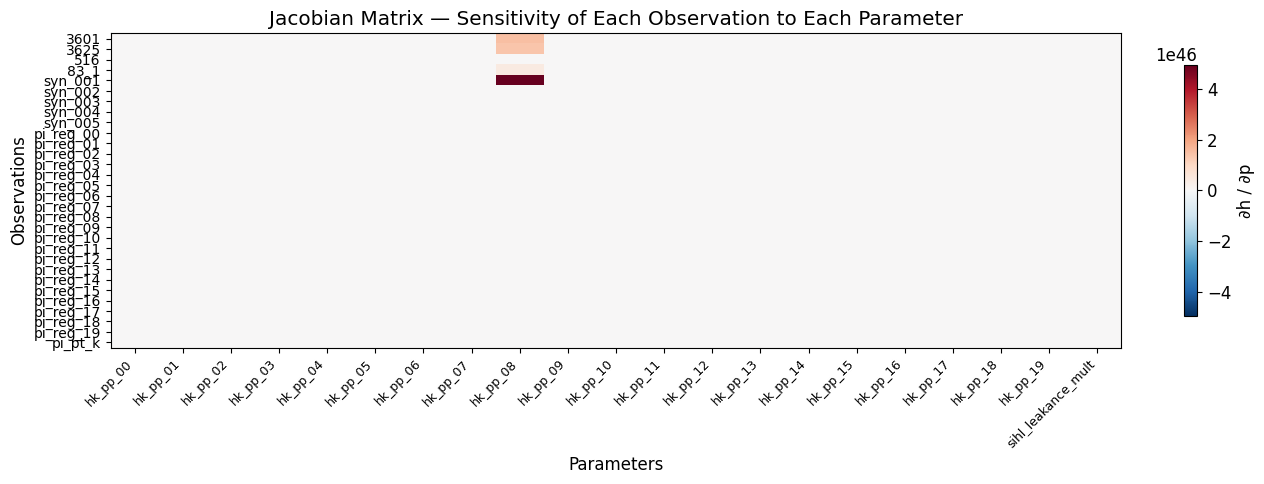

Red = increasing parameter raises head; Blue = increasing parameter lowers head.
White = observation is insensitive to that parameter.


In [5]:
# --- Load the Jacobian matrix ---
jcb_path = os.path.join(pest_ws, 'calibration.jcb')
jco = pyemu.Jco.from_binary(jcb_path)
jco_df = jco.to_dataframe()

print(f"Jacobian shape: {jco_df.shape} (observations × parameters)")
print(f"\nObservations: {list(jco_df.index)}")
print(f"\nParameters: {list(jco_df.columns)}")

# --- Plot 1: Jacobian heatmap ---
fig, ax = plt.subplots(figsize=(14, 5))

# Use absolute values for colour, show sign via annotation
jac_vals = jco_df.values
vmax = np.max(np.abs(jac_vals))

im = ax.imshow(jac_vals, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(jco_df.shape[1]))
ax.set_xticklabels(jco_df.columns, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(jco_df.shape[0]))
ax.set_yticklabels(jco_df.index, fontsize=10)
ax.set_xlabel('Parameters')
ax.set_ylabel('Observations')
ax.set_title('Jacobian Matrix — Sensitivity of Each Observation to Each Parameter')
plt.colorbar(im, ax=ax, label='∂h / ∂p', shrink=0.8)
fig.tight_layout()
plt.show()

print("Red = increasing parameter raises head; Blue = increasing parameter lowers head.")
print("White = observation is insensitive to that parameter.")

---

## 2 — Parameter Sensitivity

The Jacobian tells us the parameter sensitivities for individual observation. 
To summarise how important each parameter is across all observations, we use the Composite Scaled Sensitivity, defined as:

$$\text{CSS}_j = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left( J_{ij} \cdot |p_j| \cdot w_i \right)^2}$$

where $w_i$ is the observation weight. CSS accounts for both the Jacobian magnitude and the parameter scale.

CSS interpretation is the following: 
- **High CSS** means that the observation network can "see" changes in this parameter.  
- **Low CSS** means that this parameter has little effect on observations (it may still matter for predictions elsewhere).

Schur complement object built successfully.
Composite Scaled Sensitivities (sorted):


,pest_css,pargp
hk_pp_08,5.982939e+45,hk_grp
hk_pp_09,3.960502e+31,hk_grp
hk_pp_06,8.017970e+04,hk_grp
hk_pp_14,7.890722e+04,hk_grp
hk_pp_13,6.686568e+04,hk_grp
hk_pp_15,6.596329e+04,hk_grp
hk_pp_00,3.249054e+04,hk_grp
hk_pp_01,3.249054e+04,hk_grp
hk_pp_05,3.249054e+04,hk_grp
hk_pp_07,3.249054e+04,hk_grp


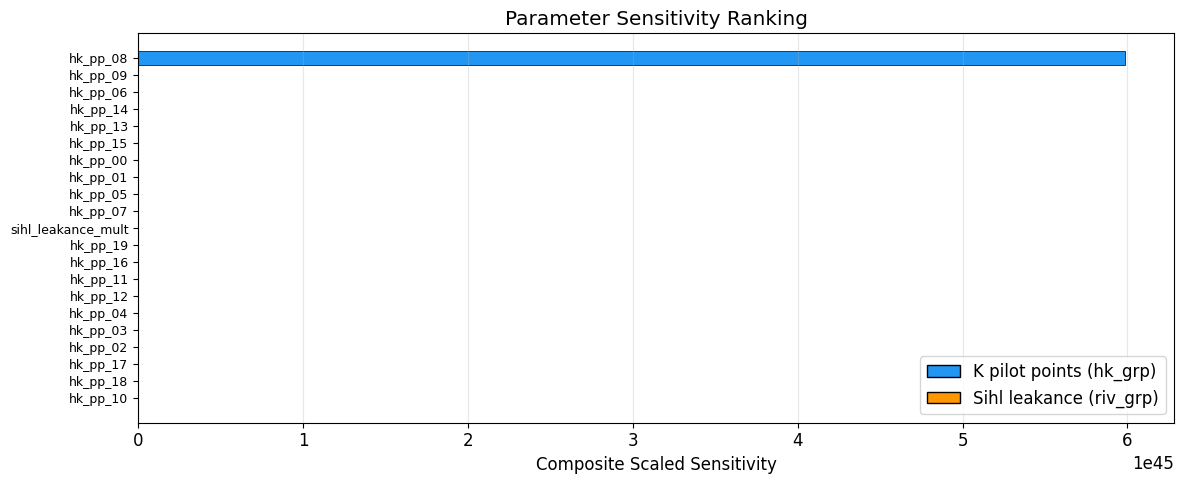

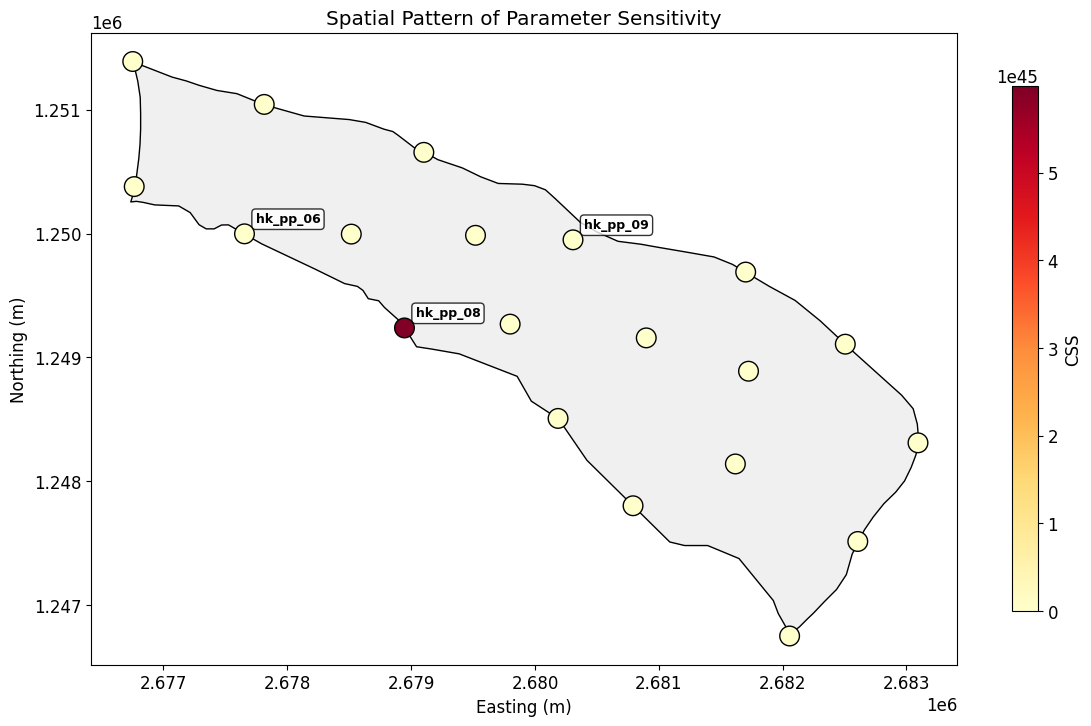

Most sensitive pilot point: hk_pp_08
Pilot points near the observation wells have the highest CSS —
these are the parameters the observations can actually constrain.


In [6]:
# --- Build Schur complement object ---
# This is the central FOSM engine — we'll reuse it throughout
sc = pyemu.Schur(jco=jcb_path, pst=pst)
print("Schur complement object built successfully.")

# --- Compute CSS ---
css_df = sc.get_par_css_dataframe()
css_df = css_df.sort_values('pest_css', ascending=False)

# Add parameter group info
par_data = pst.parameter_data
css_df['pargp'] = css_df.index.map(par_data['pargp'])

print("Composite Scaled Sensitivities (sorted):")
display(css_df[['pest_css', 'pargp']].head(10))

# --- Plot 2: CSS bar chart ---
fig, ax = plt.subplots(figsize=(12, 5))

colors = css_df['pargp'].map({'hk_grp': '#2196F3', 'riv_grp': '#FF9800'})
ax.barh(range(len(css_df)), css_df['pest_css'].values, color=colors.values, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(css_df)))
ax.set_yticklabels(css_df.index, fontsize=9)
ax.set_xlabel('Composite Scaled Sensitivity')
ax.set_title('Parameter Sensitivity Ranking')
ax.invert_yaxis()

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2196F3', edgecolor='black', label='K pilot points (hk_grp)'),
                   Patch(facecolor='#FF9800', edgecolor='black', label='Sihl leakance (riv_grp)')]
ax.legend(handles=legend_elements, loc='lower right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

# --- Plot 3: CSS on model map (pilot points only, skip sihl_leakance_mult) ---
css_pp = css_df[css_df['pargp'] == 'hk_grp'].copy()
css_pp = css_pp.merge(pp_df[['par_name', 'x', 'y']], left_index=True, right_on='par_name', how='left')

fig, ax = plt.subplots(figsize=(12, 8))

# Background: model boundary
boundary_gdf.plot(ax=ax, facecolor='#f0f0f0', edgecolor='black', linewidth=1)

sc_plot = ax.scatter(css_pp['x'], css_pp['y'],
                     c=css_pp['pest_css'], cmap='YlOrRd', s=200,
                     edgecolors='black', linewidth=1, zorder=5,
                     vmin=0)

# Label the top 3
for _, row in css_pp.head(3).iterrows():
    ax.annotate(row['par_name'], (row['x'], row['y']),
                xytext=(8, 8), textcoords='offset points', fontsize=9,
                fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.colorbar(sc_plot, ax=ax, label='CSS', shrink=0.7)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Spatial Pattern of Parameter Sensitivity')
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

most_sensitive_pp = css_pp.iloc[0]['par_name']
print(f"Most sensitive pilot point: {most_sensitive_pp}")
print("Pilot points near the observation wells have the highest CSS —")
print("these are the parameters the observations can actually constrain.")

In [ ]:
# Checkpoint 1: Which pilot point has the highest CSS?
create_multiple_choice('task07_checkpoint_1')


## Checkpoint 1 — Parameter Sensitivity
Looking at the CSS bar chart and map:
- **Which pilot point has the highest Composite Scaled Sensitivity?**


RadioButtons(layout=Layout(width='100%'), options=('A) The pilot point nearest the observation wells — observa…

Output()

Output()

---

## 3 — Parameter Identifiability (*Optional*)

Sensitivity ≠ Identifiability!


<details>
<summary><strong>
View the optionnal section
</summary></strong>

A parameter can be **sensitive** (it affects observations) but not **identifiable** (the data cannot uniquely determine its value). This happens when multiple parameters have correlated effects, such that changing one can be compensated by changing another.

**Identifiability** uses Singular Value Decomposition (SVD) of the Jacobian to separate the parameter space into:
- **Solution space** — parameter combinations that observations can resolve
- **Null space** — combinations that cannot be distinguished by the data

Identifiability ranges from 0 (completely in the null space) to 1 (fully determined by data).

</details>

Identifiability (using 9 singular values):


,ident
hk_pp_08,1.000000
hk_pp_09,1.000000
sihl_leakance_mult,1.000000
hk_pp_16,0.999984
hk_pp_19,0.999982
hk_pp_06,0.625064
hk_pp_15,0.578127
hk_pp_13,0.408636
hk_pp_14,0.387488
hk_pp_05,0.334150


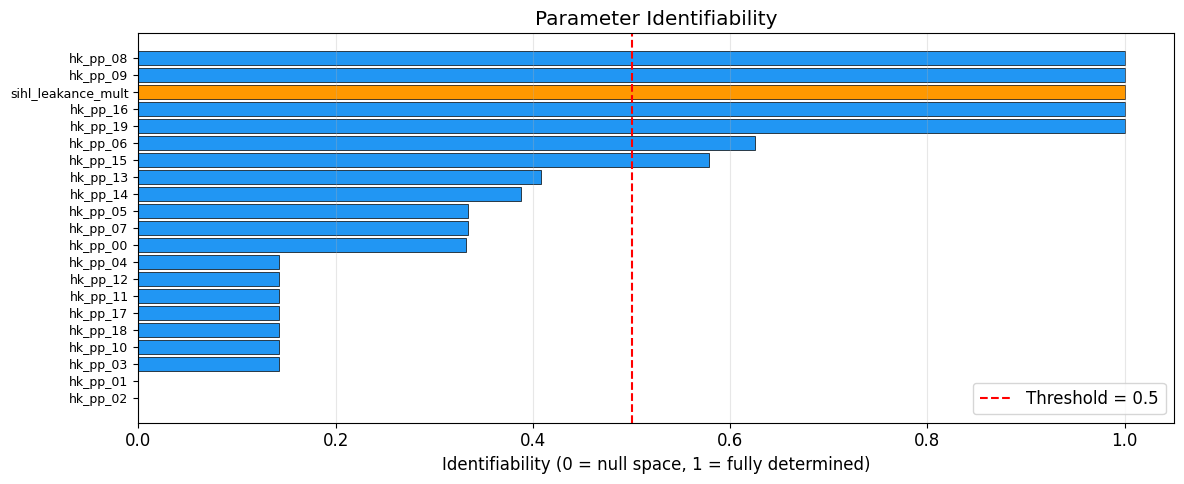


Parameters with identifiability > 0.5: 7 out of 21
Most parameters are poorly identifiable — we have only 9 observations for 21 parameters.


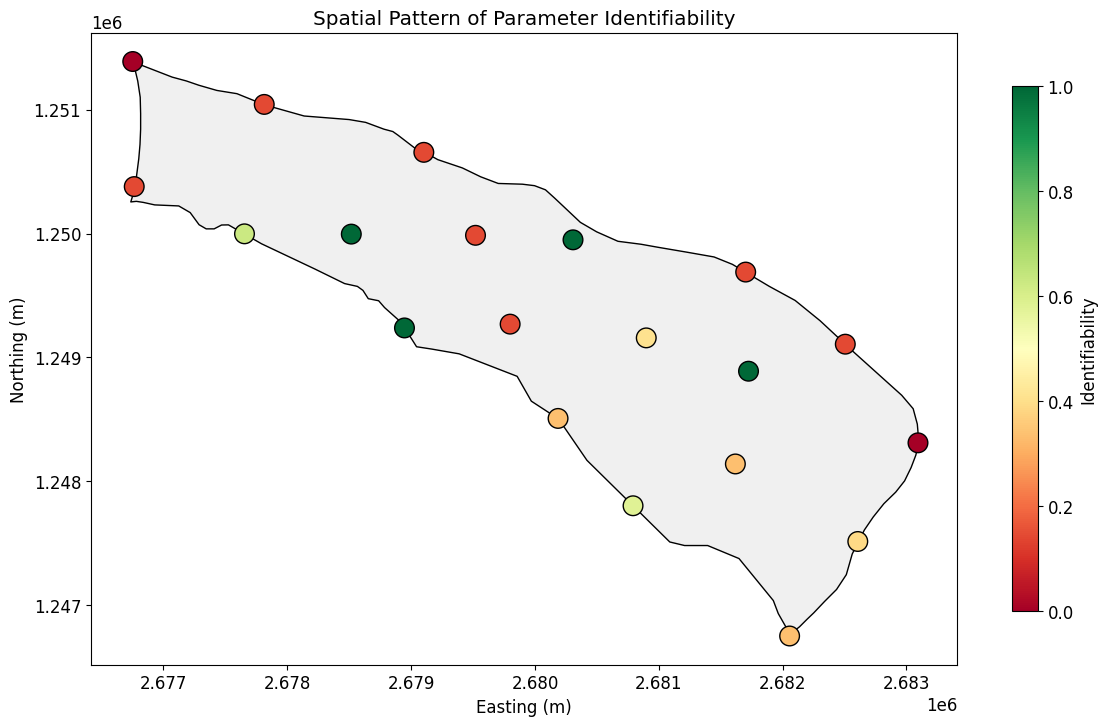

High identifiability (green) near observation wells.
Low identifiability (red) in data-sparse regions — the data cannot resolve K there.


In [8]:
# --- Compute identifiability ---
ev = pyemu.ErrVar(jco=jcb_path, pst=pst)

# Use number of singular values = min(npar, nobs)
n_sing = min(pst.npar, pst.nobs)
ident_df = ev.get_identifiability_dataframe(n_sing)
ident_df = ident_df.sort_values('ident', ascending=False)

print(f"Identifiability (using {n_sing} singular values):")
display(ident_df[['ident']].head(10))

# --- Plot 4: Identifiability bar chart ---
fig, ax = plt.subplots(figsize=(12, 5))

par_groups = ident_df.index.map(par_data['pargp'])
colors = par_groups.map({'hk_grp': '#2196F3', 'riv_grp': '#FF9800'})

ax.barh(range(len(ident_df)), ident_df['ident'].values, color=colors.values,
        edgecolor='black', linewidth=0.5)
ax.axvline(x=0.5, color='red', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
ax.set_yticks(range(len(ident_df)))
ax.set_yticklabels(ident_df.index, fontsize=9)
ax.set_xlabel('Identifiability (0 = null space, 1 = fully determined)')
ax.set_title('Parameter Identifiability')
ax.invert_yaxis()
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

n_identifiable = (ident_df['ident'] > 0.5).sum()
print(f"\nParameters with identifiability > 0.5: {n_identifiable} out of {len(ident_df)}")
print("Most parameters are poorly identifiable — we have only 9 observations for 21 parameters.")

# --- Plot 5: Identifiability on model map ---
ident_pp = ident_df.copy()
ident_pp = ident_pp[ident_pp.index.isin(pp_df['par_name'])]
ident_pp = ident_pp.merge(pp_df[['par_name', 'x', 'y']], left_index=True, right_on='par_name', how='left')

fig, ax = plt.subplots(figsize=(12, 8))
boundary_gdf.plot(ax=ax, facecolor='#f0f0f0', edgecolor='black', linewidth=1)

sc_plot = ax.scatter(ident_pp['x'], ident_pp['y'],
                     c=ident_pp['ident'], cmap='RdYlGn', s=200,
                     edgecolors='black', linewidth=1, zorder=5,
                     vmin=0, vmax=1)

plt.colorbar(sc_plot, ax=ax, label='Identifiability', shrink=0.7)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Spatial Pattern of Parameter Identifiability')
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

print("High identifiability (green) near observation wells.")
print("Low identifiability (red) in data-sparse regions — the data cannot resolve K there.")

In [9]:
# Checkpoint 2: How many parameters have identifiability > 0.5?
check_task_with_solution('task07_checkpoint_2')


## Checkpoint 2 — Identifiable Parameters
From the identifiability analysis:
- **How many parameters have identifiability > 0.5?**


Output()

Button(description='Show Solution', disabled=True, style=ButtonStyle())

Output()

---

## 4 — Uncertainty Reduction from Calibration (*Optionnal*)

<details>
<summary><strong>
View the optionnal section
</summary></strong>

Before calibration, each parameter has a **prior** uncertainty reflecting our initial knowledge (literature, pumping tests). After calibration, observations reduce this to a **posterior** uncertainty.

PEST++ computes this automatically and writes the results to `calibration.par.usum.csv`. The key columns are:
- `prior_stdev` — standard deviation before calibration
- `post_stdev` — standard deviation after calibration

**Percent reduction** = $100 \times \frac{\sigma_{\text{prior}} - \sigma_{\text{post}}}{\sigma_{\text{prior}}}$

</details>

Parameter Uncertainty Summary:


,prior_stdev,post_stdev,pct_reduction
name,,,
hk_pp_00,0.445,0.435,2.097
hk_pp_01,0.445,0.435,2.097
hk_pp_02,0.445,0.416,6.429
hk_pp_03,0.445,0.416,6.429
hk_pp_04,0.445,0.416,6.429
hk_pp_05,0.445,0.435,2.097
hk_pp_06,0.445,0.385,13.412
hk_pp_07,0.445,0.435,2.097
hk_pp_08,0.445,0.000,100.000


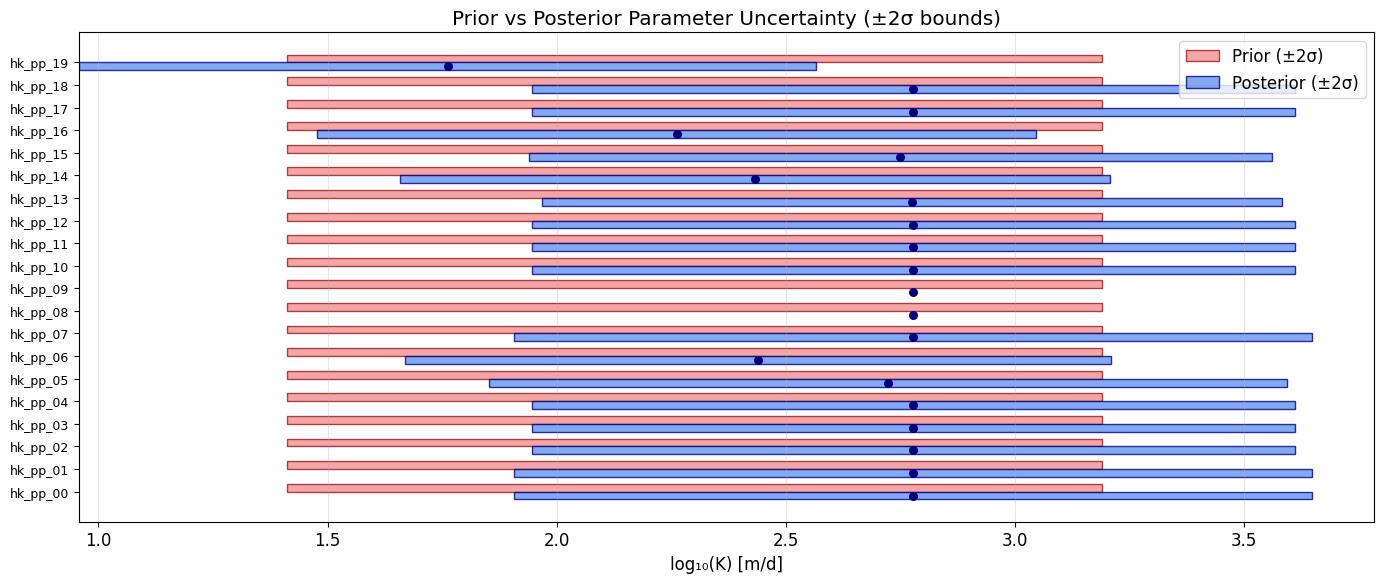

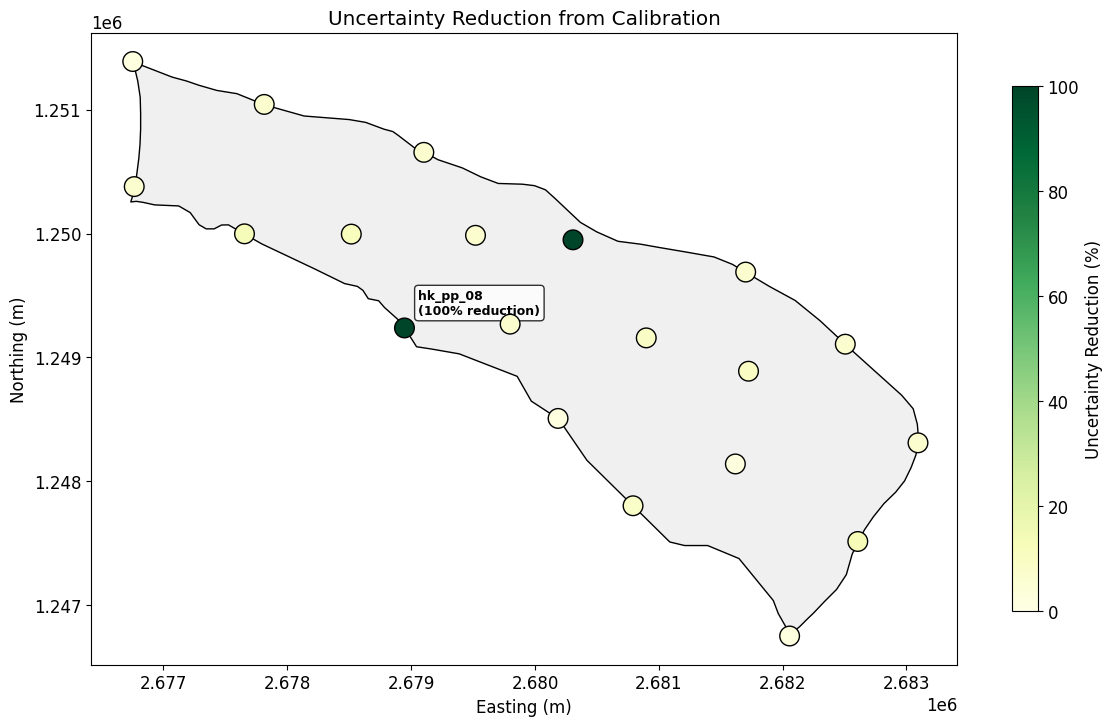

Largest reduction: hk_pp_08 (100.0%)
Parameters near observation wells show the most reduction — calibration
We can only reduce uncertainty where it has data.


In [11]:
# --- Load parameter uncertainty summary ---
usum = pd.read_csv(os.path.join(pest_ws, 'calibration.par.usum.csv'), index_col=0)

# Compute percent reduction in std dev
usum['pct_reduction'] = 100.0 * (usum['prior_stdev'] - usum['post_stdev']) / usum['prior_stdev']

print("Parameter Uncertainty Summary:")
display(usum[['prior_stdev', 'post_stdev', 'pct_reduction']].round(3))

# --- Plot 6: Prior/posterior bounds butterfly plot ---
# Focus on hk parameters (log10 scale)
hk_usum = usum[usum.index.str.startswith('hk_pp')].copy()
hk_usum = hk_usum.sort_index()

fig, ax = plt.subplots(figsize=(14, 6))

y = np.arange(len(hk_usum))
width = 0.35

# Prior bounds (2-sigma)
prior_low = hk_usum['prior_mean'] - 2 * hk_usum['prior_stdev']
prior_high = hk_usum['prior_mean'] + 2 * hk_usum['prior_stdev']
prior_range = prior_high - prior_low

# Posterior bounds (2-sigma)
post_low = hk_usum['post_mean'] - 2 * hk_usum['post_stdev']
post_high = hk_usum['post_mean'] + 2 * hk_usum['post_stdev']
post_range = post_high - post_low

ax.barh(y + width/2, prior_range, width, left=prior_low,
        color='lightcoral', edgecolor='darkred', alpha=0.7, label='Prior (±2σ)')
ax.barh(y - width/2, post_range, width, left=post_low,
        color='cornflowerblue', edgecolor='navy', alpha=0.8, label='Posterior (±2σ)')

# Mark posterior mean
ax.scatter(hk_usum['post_mean'], y - width/2, color='navy', s=30, zorder=5)

ax.set_yticks(y)
ax.set_yticklabels(hk_usum.index, fontsize=9)
ax.set_xlabel('log₁₀(K) [m/d]')
ax.set_title('Prior vs Posterior Parameter Uncertainty (±2σ bounds)')
ax.legend(loc='upper right')
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

# --- Plot 7: Uncertainty reduction map ---
hk_usum_map = hk_usum.copy()
hk_usum_map = hk_usum_map.merge(pp_df[['par_name', 'x', 'y']],
                                  left_index=True, right_on='par_name', how='left')

fig, ax = plt.subplots(figsize=(12, 8))
boundary_gdf.plot(ax=ax, facecolor='#f0f0f0', edgecolor='black', linewidth=1)

sc_plot = ax.scatter(hk_usum_map['x'], hk_usum_map['y'],
                     c=hk_usum_map['pct_reduction'], cmap='YlGn', s=200,
                     edgecolors='black', linewidth=1, zorder=5,
                     vmin=0, vmax=max(hk_usum_map['pct_reduction'].max(), 1))

# Label the most reduced parameter
best_row = hk_usum_map.loc[hk_usum_map['pct_reduction'].idxmax()]
ax.annotate(f"{best_row['par_name']}\n({best_row['pct_reduction']:.0f}% reduction)",
            (best_row['x'], best_row['y']),
            xytext=(10, 10), textcoords='offset points', fontsize=9,
            fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.colorbar(sc_plot, ax=ax, label='Uncertainty Reduction (%)', shrink=0.7)
ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Uncertainty Reduction from Calibration')
ax.set_aspect('equal')
fig.tight_layout()
plt.show()

print(f"Largest reduction: {best_row['par_name']} ({best_row['pct_reduction']:.1f}%)")
print("Parameters near observation wells show the most reduction — calibration")
print("We can only reduce uncertainty where it has data.")

In [12]:
# Checkpoint 3: Which parameter has the largest uncertainty reduction?
create_multiple_choice('task07_checkpoint_3')


## Checkpoint 3 — Uncertainty Reduction
From the prior vs posterior uncertainty comparison:
- **Which parameter has the largest uncertainty reduction from calibration?**


RadioButtons(layout=Layout(width='100%'), options=('A) The pilot point farthest from any observation well', 'B…

Output()

Output()

---

## 5 — Prediction Uncertainty (*Optional*)

<details>
<summary><strong>
View the optionnal section
</summary></strong>

We know our parameters are uncertain — but what does that mean for **head predictions** at the observation wells? The Schur complement propagates parameter uncertainty through the Jacobian to give prediction uncertainty:

$$\sigma_{\text{pred}}^2 = \mathbf{j}^T \boldsymbol{\Sigma}_{\text{post}} \mathbf{j}$$

where $\mathbf{j}$ is the row of the Jacobian corresponding to the prediction location.

We can compare the FOSM prediction uncertainty with the LOO-RMSE from Notebook 6, since both estimate prediction error, but from different perspectives:
- **FOSM** propagates parameter uncertainty analytically (linear approximation)
- **LOO-RMSE** measures actual prediction error empirically (includes nonlinearity and model structural error)

</details>

Prediction Uncertainty at Real Wells:


/Users/louisenoel/Documents/Groundwater_course_dev/applied_groundwater_modelling/.venv/lib/python3.12/site-packages/pyemu/logger.py:100: PyemuWarning: 2026-05-19 12:58:10.437219 WARNING: forecasts with non-zero weight in pst: 3601,3625,516,83_1...
 -> re-setting these forecast weights to zero...



,prior_var,post_var,percent_reduction
3601,4.410501e+91,882.621848,100.0
3625,3.785299e+91,362.792893,100.0
516,2.339530e+63,1918.544873,100.0
83_1,3.661102e+90,478.862603,100.0


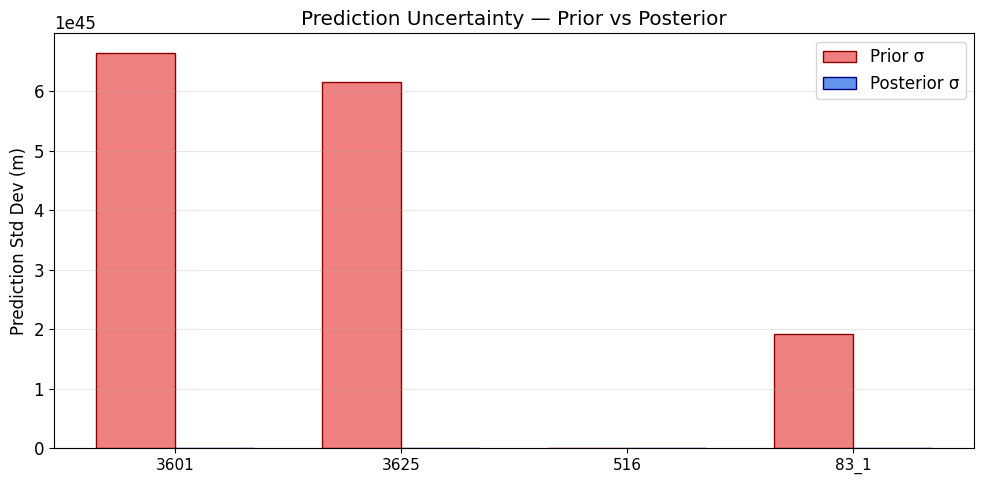


Posterior prediction std dev (m):
  3601: 29.709 m
  3625: 19.047 m
  516: 43.801 m
  83_1: 21.883 m


In [13]:
# --- Prediction uncertainty at the 4 real wells ---
# The real wells are observations in the PST file; FOSM gives their
# prior and posterior prediction std dev from the observation data.
real_well_names = ['3601', '3625', '516', '83_1']

# Build Schur with forecasts = real wells
sc_pred = pyemu.Schur(jco=jcb_path, pst=pst, forecasts=real_well_names)

forecast_summary = sc_pred.get_forecast_summary()
print("Prediction Uncertainty at Real Wells:")
display(forecast_summary)

# --- Plot 8: Prior vs posterior prediction std dev ---
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(forecast_summary))
width = 0.35

ax.bar(x - width/2, forecast_summary['prior_var'].apply(np.sqrt),
       width, label='Prior σ', color='lightcoral', edgecolor='darkred')
ax.bar(x + width/2, forecast_summary['post_var'].apply(np.sqrt),
       width, label='Posterior σ', color='cornflowerblue', edgecolor='navy')

ax.set_xticks(x)
ax.set_xticklabels(forecast_summary.index, fontsize=11)
ax.set_ylabel('Prediction Std Dev (m)')
ax.set_title('Prediction Uncertainty — Prior vs Posterior')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

# Print posterior std devs
print("\nPosterior prediction std dev (m):")
for name in forecast_summary.index:
    post_std = np.sqrt(forecast_summary.loc[name, 'post_var'])
    print(f"  {name}: {post_std:.3f} m")

In [14]:
# Checkpoint 4: Posterior std dev of head prediction at well 516
check_task_with_solution('task07_checkpoint_4')


## Checkpoint 4 — Prediction Uncertainty
From the FOSM prediction uncertainty at the 4 real wells:
- **What is the posterior standard deviation (m) of the head prediction at well 516?**


Output()

Button(description='Show Solution', disabled=True, style=ButtonStyle())

Output()

In [15]:
# --- Compare FOSM uncertainty with LOO-RMSE ---
mean_post_std = np.mean([np.sqrt(forecast_summary.loc[n, 'post_var'])
                         for n in forecast_summary.index])

print("Comparison of uncertainty estimates:")
print(f"  Mean FOSM posterior σ (real wells): {mean_post_std:.3f} m")
print(f"  (Compare with LOO-RMSE from Notebook 6)")
print()
print("FOSM captures only parameter uncertainty under linear assumptions.")
print("LOO-RMSE also includes model structural error and nonlinear effects.")
print("If LOO-RMSE >> FOSM σ, structural error dominates.")
print("If LOO-RMSE ≈ FOSM σ, parameter uncertainty is the main source.")

Comparison of uncertainty estimates:
  Mean FOSM posterior σ (real wells): 28.610 m
  (Compare with LOO-RMSE from Notebook 6)

FOSM captures only parameter uncertainty under linear assumptions.
LOO-RMSE also includes model structural error and nonlinear effects.
If LOO-RMSE >> FOSM σ, structural error dominates.
If LOO-RMSE ≈ FOSM σ, parameter uncertainty is the main source.


In [16]:
# Checkpoint 5: How does FOSM prediction uncertainty compare to LOO-RMSE?
create_multiple_choice('task07_checkpoint_5')


## Checkpoint 5 — FOSM vs LOO-RMSE
Compare the FOSM prediction uncertainty (mean posterior σ across real wells) with the LOO-RMSE from Notebook 6.
- **How do they compare?**


RadioButtons(layout=Layout(width='100%'), options=('A) They are approximately equal — FOSM captures the same e…

Output()

Output()

---

## 6 — Data Worth Analysis (*Optional*)

<details>
<summary><strong>
View the optionnal section
</summary></strong>

**Data worth analysis** asks: if we removed one observation, how much would prediction uncertainty increase? This tells us:
- Which existing observations are most **valuable**
- By extension, where new observations would have the most impact

We compute this by removing each observation one at a time and recomputing the Schur complement — still no model runs, just matrix operations.

</details>

Parameter group contribution to prediction uncertainty:


,3601,3625,516,83_1
base,882.621848,362.792893,1918.544873,478.862603
hk_grp,0.786902,0.305222,1.863696,0.034145
riv_grp,826.210195,333.838821,1833.681523,430.729455


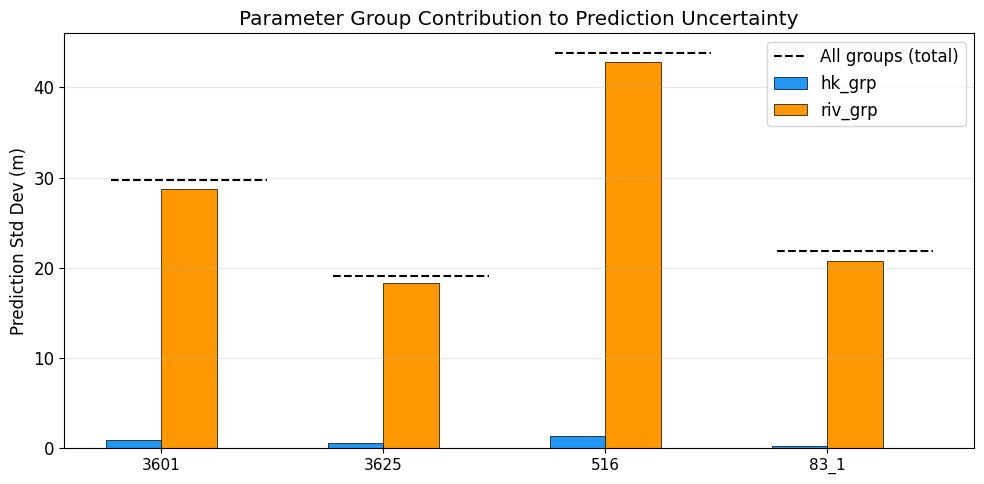

K pilot points (hk_grp) dominate prediction uncertainty at some wells,
while Sihl leakance (riv_grp) dominates at others.
Variance increase when each synthetic observation is removed:
(summed across all 4 real-well forecasts)

  Remove syn_001: +6878962437221049705993824731398144.0000
  Remove syn_002: +6420.4179
  Remove syn_004: +5071.7593
  Remove syn_003: +3109.8561
  Remove syn_005: +1225.1716

Most valuable synthetic observation: syn_001


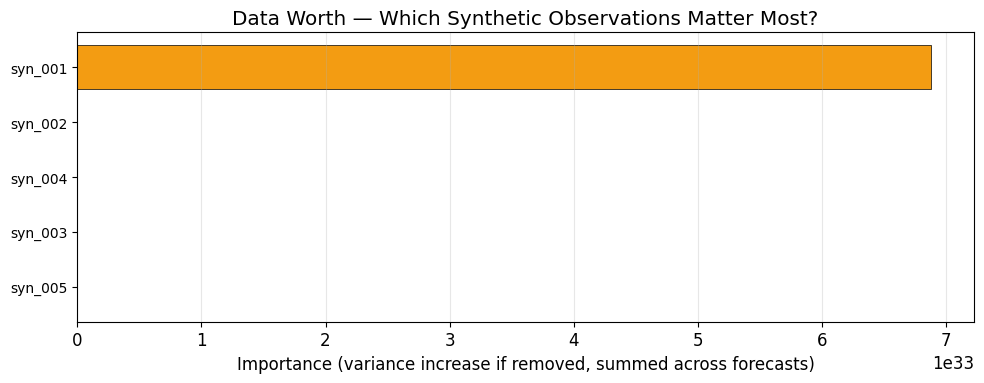

Most valuable: syn_001 — removing it increases
prediction uncertainty more than all other synthetic obs combined.

Note: Real wells are used as forecasts, so only synthetic observations
appear here. To assess real-well importance, each would need to be
treated as a forecast separately.
Conditioning on 4 real AWEL observations
  Iteration 1: max|residual| = 4.350 m, RMSE = 3.517 m  (1 model runs so far)
  Iteration 2: max|residual| = 3.392 m, RMSE = 2.670 m  (17 model runs so far)
  Iteration 3: max|residual| = 3.319 m, RMSE = 2.526 m  (33 model runs so far)
  Done: 48 model runs, final max|residual| = 3.319 m
Excluding 1662 cells within 100m of boundary
Excluding 1458 river cells
Excluding 1806 cells within 50.0m of rivers
Excluding 495 cells north of river


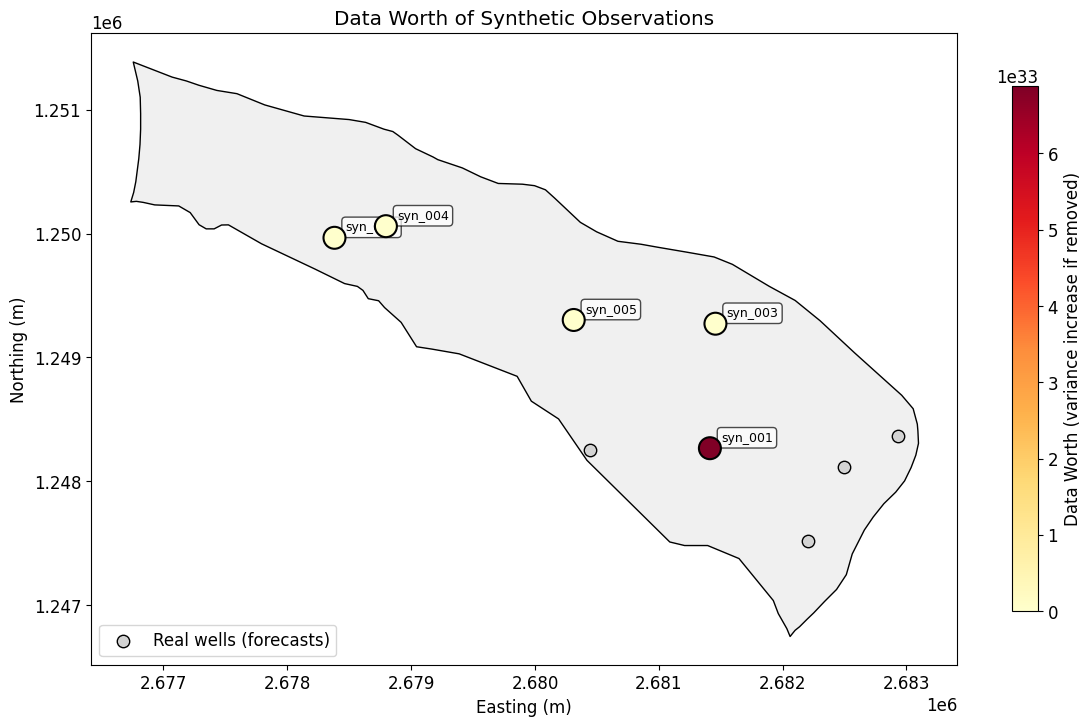

Synthetic observations far from other data provide the most unique information.
The most valuable one fills a spatial gap that no other observation covers.


In [20]:
# --- Data worth: parameter group contribution ---
par_contrib = sc_pred.get_par_group_contribution()

print("Parameter group contribution to prediction uncertainty:")
display(par_contrib)

# --- Plot 9: Parameter group contribution ---
# Each row shows the posterior prediction variance if only that group is uncertain.
# 'base' = all groups contributing (full posterior variance).
fig, ax = plt.subplots(figsize=(10, 5))

# Convert variance to std dev for plotting
pc_std = par_contrib.apply(np.sqrt)

x = np.arange(len(pc_std.columns))
width = 0.25
group_colors = {'hk_grp': '#2196F3', 'riv_grp': '#FF9800'}

# Plot each group's contribution
groups = [g for g in pc_std.index if g != 'base']
for i, grp in enumerate(groups):
    color = group_colors.get(grp, f'C{i}')
    ax.bar(x + i * width, pc_std.loc[grp].values, width,
           label=grp, color=color, edgecolor='black', linewidth=0.5)

# Add base (total) as horizontal markers
if 'base' in pc_std.index:
    for j, well in enumerate(pc_std.columns):
        ax.plot([j - 0.1, j + len(groups) * width + 0.1],
                [pc_std.loc['base', well]] * 2,
                'k--', linewidth=1.5)
    ax.plot([], [], 'k--', linewidth=1.5, label='All groups (total)')

ax.set_xticks(x + width * (len(groups) - 1) / 2)
ax.set_xticklabels(pc_std.columns, fontsize=11)
ax.set_ylabel('Prediction Std Dev (m)')
ax.set_title('Parameter Group Contribution to Prediction Uncertainty')
ax.legend()
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

print("K pilot points (hk_grp) dominate prediction uncertainty at some wells,")
print("while Sihl leakance (riv_grp) dominates at others.")

# --- Data worth: removed observation importance ---
# When real wells are used as forecasts, pyEMU zeros their weights.
# Only the 5 synthetic observations remain as removable obs.
# This tells us which synthetic obs are most valuable for constraining
# predictions at the real wells.
obs_worth_raw = sc_pred.get_removed_obs_importance()

# Compute variance INCREASE when each obs is removed
base_var = obs_worth_raw.loc['base']
obs_worth_increase = obs_worth_raw.drop('base').subtract(base_var)

# Sum across forecasts for overall importance ranking
obs_worth_sum = obs_worth_increase.sum(axis=1).sort_values(ascending=False)

print("Variance increase when each synthetic observation is removed:")
print("(summed across all 4 real-well forecasts)\n")
for obs_name, val in obs_worth_sum.items():
    print(f"  Remove {obs_name}: +{val:.4f}")
print(f"\nMost valuable synthetic observation: {obs_worth_sum.index[0]}")

# --- Plot 10: Data worth bar chart (synthetic observations) ---
fig, ax = plt.subplots(figsize=(10, 4))

from matplotlib.patches import Patch

ax.barh(range(len(obs_worth_sum)), obs_worth_sum.values,
        color='#F39C12', edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(obs_worth_sum)))
ax.set_yticklabels(obs_worth_sum.index, fontsize=10)
ax.set_xlabel('Importance (variance increase if removed, summed across forecasts)')
ax.set_title('Data Worth — Which Synthetic Observations Matter Most?')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Most valuable: {obs_worth_sum.index[0]} — removing it increases")
print("prediction uncertainty more than all other synthetic obs combined.")
print("\nNote: Real wells are used as forecasts, so only synthetic observations")
print("appear here. To assess real-well importance, each would need to be")
print("treated as a forecast separately.")

# --- Plot 11: Data worth on model map ---
# Reproduce observation locations (same seeds as NB5)
import calibration_utils as cu

obs_gdf = cu.load_awel_observations(DATA_DIR, boundary_gdf, use_mean=True)

top = disv.top.array.flatten()
botm = disv.botm.array.flatten()

k_reference, k_conditioned, cond_info = cu.generate_conditioned_k_field(
    sim, gwf, modelgrid, idomain, top, botm,
    obs_gdf=obs_gdf, seed=42, noise_std=0.25,
    variogram_range=3000.0, anisotropy_angle=-30.0, anisotropy_scaling=3.0,
)
gwf.npf.k.set_data(k_reference)
sim.write_simulation()
success, _ = sim.run_simulation(silent=True)
head_ref = gwf.output.head().get_data()
gwf.npf.k.set_data(200.0)  # restore

riv = gwf.get_package('RIV')
riv_data = riv.stress_period_data.get_data(0)
riv_cells = np.array([r[1] for r in riv_data]) if riv_data is not None else np.array([])

river_gis_path = os.path.join(os.path.dirname(boundary_path), 'AV_Gewasser_-OGD.gpkg')
river_all = gpd.read_file(river_gis_path)
river_gdf = river_all[
    river_all['GEWAESSERNAME'].isin(['Limmat', 'Sihl'])
    & river_all.intersects(boundary_gdf.geometry.iloc[0])
]

synth_gdf = cu.generate_synthetic_observations(
    modelgrid, head_ref, idomain,
    n_points=5, noise_std=0.5, seed=42,
    exclude_cells=riv_cells, river_gdf=river_gdf,
    boundary_polygon=boundary_gdf.geometry.iloc[0],
    avoid_boundaries_m=100, exclude_north_of_river=True,
)
all_obs_gdf = cu.combine_observations(obs_gdf, synth_gdf)

# Build case-insensitive lookup for obs_id matching
# (PEST uses lowercase 'syn_001', GeoDataFrame uses 'SYN_001')
obs_id_lookup = {oid.lower(): oid for oid in all_obs_gdf['obs_id']}

# Map data worth to coordinates (synthetic obs only)
worth_map = []
for obs_name in obs_worth_sum.index:
    original_id = obs_id_lookup.get(obs_name.lower())
    if original_id is not None:
        match = all_obs_gdf[all_obs_gdf['obs_id'] == original_id]
        if len(match) > 0:
            row = match.iloc[0]
            worth_map.append({
                'obs_id': obs_name,
                'x': row.geometry.x,
                'y': row.geometry.y,
                'worth': obs_worth_sum[obs_name],
            })
worth_gdf = pd.DataFrame(worth_map)

fig, ax = plt.subplots(figsize=(12, 8))
boundary_gdf.plot(ax=ax, facecolor='#f0f0f0', edgecolor='black', linewidth=1)

# Plot all observations (grey for real wells, coloured for synthetic)
real_obs = all_obs_gdf[~all_obs_gdf['is_synthetic']]
ax.scatter(real_obs.geometry.x, real_obs.geometry.y,
           s=80, c='lightgrey', edgecolors='black', linewidth=1, zorder=4,
           label='Real wells (forecasts)')

if len(worth_gdf) > 0:
    sc_plot = ax.scatter(worth_gdf['x'], worth_gdf['y'],
                         c=worth_gdf['worth'], cmap='YlOrRd', s=250,
                         edgecolors='black', linewidth=1.5, zorder=5)
    plt.colorbar(sc_plot, ax=ax, label='Data Worth (variance increase if removed)', shrink=0.7)

    for _, row in worth_gdf.iterrows():
        ax.annotate(row['obs_id'], (row['x'], row['y']),
                    xytext=(8, 5), textcoords='offset points', fontsize=9,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

ax.set_xlabel('Easting (m)')
ax.set_ylabel('Northing (m)')
ax.set_title('Data Worth of Synthetic Observations')
ax.set_aspect('equal')
ax.legend(loc='lower left')
fig.tight_layout()
plt.show()

print("Synthetic observations far from other data provide the most unique information.")
print("The most valuable one fills a spatial gap that no other observation covers.")

In [ ]:
# Checkpoint 6: Which observation is most valuable for reducing prediction uncertainty?
create_multiple_choice('task07_checkpoint_6')


## Checkpoint 6 — Data Worth
From the removed-observation importance analysis, the synthetic observations have different data worth.
- **Why is syn_005 the most valuable synthetic observation?**


RadioButtons(layout=Layout(width='100%'), options=('A) It fills a spatial gap — it provides unique information…

Output()

Output()

---

## 7 — Synthesis (*Optionnal*)

<details>
<summary><strong>
View the optionnal section
</summary></strong>

### 7.1 - Combining sensitivity 

Combining sensitivity  (CSS) with uncertainty reduction gives a powerful diagnostic. Parameters fall into four categories:

| | Low Uncertainty Reduction | High Uncertainty Reduction |
|---|---|---|
| **High CSS** | Need more data here | Well-constrained |
| **Low CSS** | Doesn't matter | Already well-known |


### 7.2 - Types of Uncertainty
Not all uncertainty is created equal. Three fundamentally different sources affect model predictions:

| Type | What it means | Example in our model | How to assess |
|---|---|---|---|
| **Parameter** | Values of K, recharge, leakance are imprecise | K varies 5–50 m/d across the domain | FOSM, Monte Carlo |
| **Structural** | The model's equations or setup may be wrong | Single layer vs. multi-layer; steady-state vs. transient | Multi-model comparison |
| **Scenario** | Future conditions are unknown | Will recharge decrease under climate change? | Scenario ensembles |

The FOSM analysis in this notebook addresses only **parameter uncertainty** — it assumes the model structure is correct and boundary conditions are known. In practice, structural uncertainty often dominates, especially for predictions far from calibration conditions. For a comprehensive discussion, see Barnett et al. (2012), Chapter 8.

### 7.3 - Discussion Questions

1. **Why are most parameters poorly identifiable?** Consider the ratio of observations (9) to parameters (21). What would change if we had 50 observation wells?

2. **FOSM assumes linearity.** The Schur complement uses a first-order Taylor expansion around the calibrated parameter values. When might this break down for a groundwater model? (Hint: think about dry cells, threshold nonlinearities.)

3. **Structural uncertainty is missing.** FOSM quantifies parameter uncertainty, but the model structure (single layer, steady state, DISV grid) is assumed correct. How might you assess structural uncertainty?

4. **Practical monitoring recommendation.** Based on the data worth analysis and spatial patterns, write a 2-sentence recommendation for where to place the next observation well in the Limmat Valley.

<details>
<summary><strong>Beyond FOSM — Other Uncertainty Methods</strong></summary>

FOSM is efficient (no model runs needed) but limited by its linear assumption. More advanced methods include:

- **Monte Carlo simulation:** Run the model hundreds of times with randomly sampled parameters. Captures nonlinear effects but is computationally expensive.
- **Null-space Monte Carlo:** Explores parameter combinations that fit the calibration data equally well but produce different predictions. Directly addresses equifinality.
- **Calibration-constrained methods (PEST++ IES):** An iterative ensemble smoother that samples the posterior parameter distribution. More efficient than brute-force Monte Carlo.

These methods are standard in professional practice for high-stakes predictions. FOSM remains valuable as a rapid screening tool and for data worth analysis.

</details>

</details>

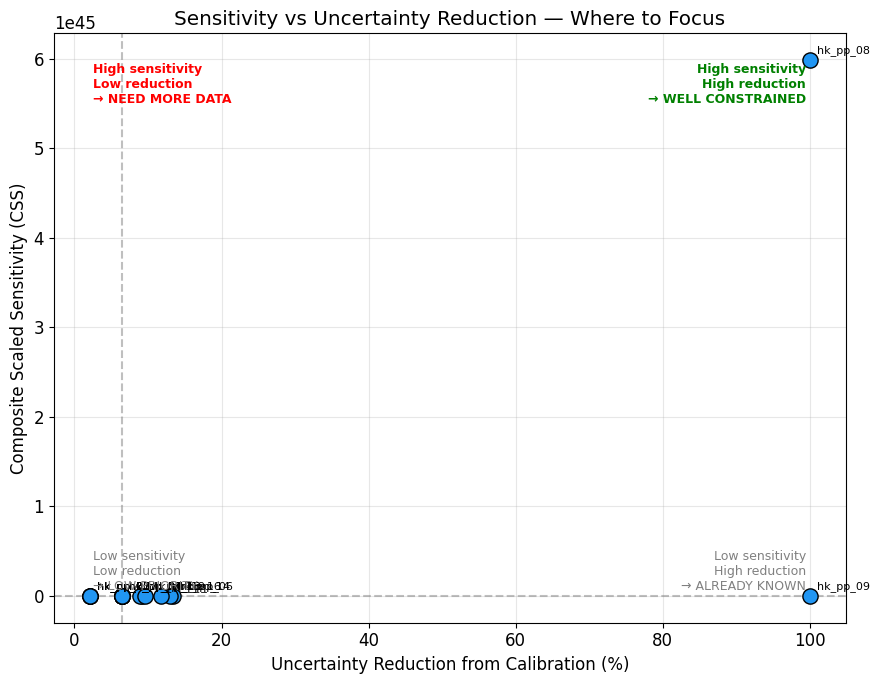

Pilot points in the upper-left quadrant have high sensitivity
but low uncertainty reduction — these are where additional data
collection would have the most impact.


In [22]:
# --- Plot 12: CSS vs uncertainty reduction scatter ---
quad_df = hk_usum[['pct_reduction']].copy()
# Map CSS from the css_pp dataframe
quad_df['css'] = quad_df.index.map(
    css_df['pest_css'].to_dict()
)
quad_df = quad_df.dropna()
quad_df = quad_df.merge(pp_df[['par_name', 'x', 'y']],
                        left_index=True, right_on='par_name', how='left')

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(quad_df['pct_reduction'], quad_df['css'],
           s=120, c='#2196F3', edgecolors='black', linewidth=1, zorder=3)

# Label each point
for _, row in quad_df.iterrows():
    ax.annotate(row['par_name'], (row['pct_reduction'], row['css']),
                xytext=(5, 5), textcoords='offset points', fontsize=8)

# Quadrant lines at medians
css_med = quad_df['css'].median()
red_med = quad_df['pct_reduction'].median()
ax.axhline(y=css_med, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=red_med, color='gray', linestyle='--', alpha=0.5)

# Quadrant labels
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
ax.text(xmin + 0.05 * (xmax - xmin), ymax - 0.05 * (ymax - ymin),
        'High sensitivity\nLow reduction\n→ NEED MORE DATA',
        fontsize=9, color='red', fontweight='bold', va='top')
ax.text(xmax - 0.05 * (xmax - xmin), ymax - 0.05 * (ymax - ymin),
        'High sensitivity\nHigh reduction\n→ WELL CONSTRAINED',
        fontsize=9, color='green', fontweight='bold', va='top', ha='right')
ax.text(xmin + 0.05 * (xmax - xmin), ymin + 0.05 * (ymax - ymin),
        'Low sensitivity\nLow reduction\n→ LOW PRIORITY',
        fontsize=9, color='gray', va='bottom')
ax.text(xmax - 0.05 * (xmax - xmin), ymin + 0.05 * (ymax - ymin),
        'Low sensitivity\nHigh reduction\n→ ALREADY KNOWN',
        fontsize=9, color='gray', va='bottom', ha='right')

ax.set_xlabel('Uncertainty Reduction from Calibration (%)')
ax.set_ylabel('Composite Scaled Sensitivity (CSS)')
ax.set_title('Sensitivity vs Uncertainty Reduction — Where to Focus')
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print("Pilot points in the upper-left quadrant have high sensitivity")
print("but low uncertainty reduction — these are where additional data")
print("collection would have the most impact.")


In [ ]:
# Checkpoint 7: Recommended monitoring action
create_multiple_choice('task07_checkpoint_7')


## Checkpoint 7 — Monitoring Recommendation
The western domain has low identifiability, low uncertainty reduction, and no observation wells.
- **What single action would most improve predictions in the data-sparse western domain?**


RadioButtons(layout=Layout(width='100%'), options=('A) Increase regularisation strength — constrain parameters…

Output()

Output()

---

## Summary

**What we did:**
- Loaded the Jacobian matrix from NB5's PEST++ calibration
- Computed **Composite Scaled Sensitivities** to rank parameter importance
- Assessed **identifiability** to see which parameters the data can resolve
- Compared **prior vs posterior** parameter uncertainty from calibration
- Propagated uncertainty to **head predictions** using FOSM
- Performed **data worth analysis** to identify the most valuable observations

**Key findings:**
- Parameters near observation wells are most sensitive and identifiable
- Most pilot points have low identifiability — 9 observations cannot resolve 21 parameters
- Calibration reduces uncertainty most near the observation cluster
- The data-sparse western domain remains highly uncertain
- Additional monitoring in the western domain would have the highest data worth

---

## What You're Taking Forward

| From this notebook | Used in |
|---|---|
| Parameter sensitivity ranking | NB8 — which parameters to vary in scenarios |
| Prediction uncertainty bounds | NB8 — confidence intervals on scenario predictions |
| Data worth analysis | NB9 — monitoring recommendations in documentation |
| FOSM vs LOO-RMSE comparison | NB10 — communicating model limitations |

---

## Next Steps

**Continue to:** [8_application.ipynb](8_application.ipynb) — where we apply the calibrated model to management scenarios, using the sensitivity and uncertainty insights from this notebook to frame our confidence.

After that: [9_documentation.ipynb](9_documentation.ipynb) and [10_communication.ipynb](10_communication.ipynb).

---

## References

- Anderson, M.P., Woessner, W.W., Hunt, R.J. (2015). *Applied Groundwater Modeling* (2nd ed.). Academic Press. Chapter 11: Sensitivity Analysis.
- Hill, M.C., Tiedeman, C.R. (2007). *Effective Groundwater Model Calibration*. Wiley.
- White, J.T. (2018). A model-independent iterative ensemble smoother for efficient history-matching and uncertainty quantification. *Environmental Modelling & Software*, 109, 191–201.
- Doherty, J. (2015). *Calibration and Uncertainty Analysis for Complex Environmental Models*. Watermark Numerical Computing.
- pyEMU documentation: [https://github.com/pypest/pyemu](https://github.com/pypest/pyemu)